Saved figure to: C:\Users\nly99857\OneDrive - Philips\SW Projects\Posts\rac_n2_posteriors.png

Configured Bloch angles:
  A  =    0.000 deg
  A' =   90.000 deg
  B  =   -0.000 deg
  B' =   90.000 deg

Conditioning on transcript: m=0, beta=0

Bob setting B:
  posterior = P(00)=0.500000, P(01)=0.250000, P(10)=0.250000, P(11)=0.000000
  H(string | transcript) = 1.500000 bits
  bit 1: best guess=0.750000, advantage=0.500000
  bit 2: best guess=0.750000, advantage=0.500000
  average RAC success for selected bit = 0.750000

Bob setting B':
  posterior = P(00)=0.250000, P(01)=0.500000, P(10)=0.000000, P(11)=0.250000
  H(string | transcript) = 1.500000 bits
  bit 1: best guess=0.750000, advantage=0.500000
  bit 2: best guess=0.750000, advantage=0.500000
  average RAC success for selected bit = 0.250000


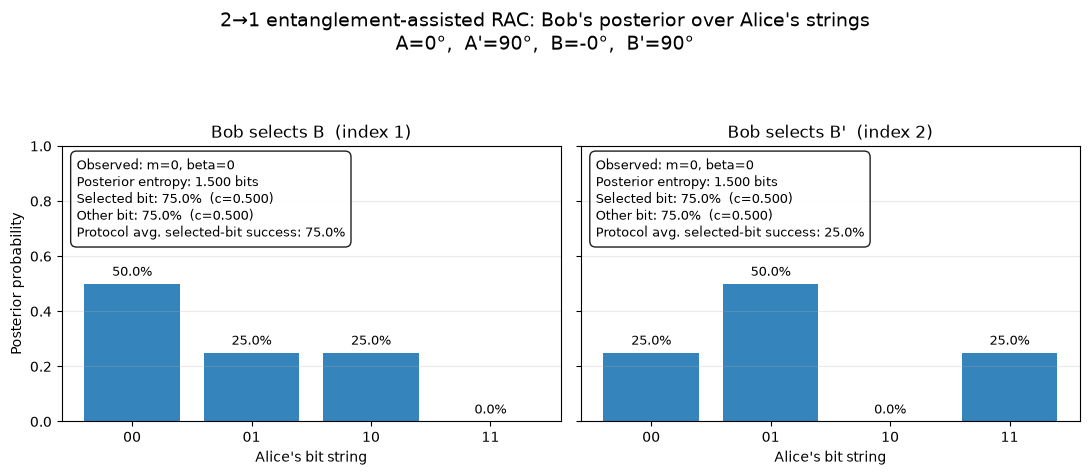

In [ ]:
#!/usr/bin/env python3
"""
2->1 entanglement-assisted RAC posterior visualizer.

Alice holds two uniformly random classical bits x0,x1.
She and Bob share |Phi+>. Alice uses the standard CHSH/RAC encoding:

    s = x0 XOR x1
    Alice measures A_s and gets outcome alpha in {0,1}
    m = x0 XOR alpha

Bob chooses y in {0,1}:
    y=0 -> measure B
    y=1 -> measure B'
    outcome beta in {0,1}
    guess g = m XOR beta

The four planar Bloch-sphere angles A, A', B, B' are configurable below.

For |Phi+> and measurements in one Bloch great circle,

    E(theta_A, theta_B) = cos(theta_A - theta_B)

and

    P(alpha,beta | theta_A,theta_B)
      = 1/4 * [1 + (-1)^(alpha XOR beta) E].

The script computes the exact Bayesian posterior over Alice's four possible
strings after Bob knows:
    * his selected setting y,
    * Alice's communication bit m,
    * his own measurement outcome beta.

No Monte-Carlo sampling is used.

Standard Tsirelson-optimal Bloch angles:
    A  =   0 deg
    A' =  90 deg
    B  =  45 deg
    B' = -45 deg
"""

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

def create_histo(alice_a, alice_aprime, bob_b, bob_bprime):
    # ============================================================
    # USER SETTINGS
    # ============================================================

    ALICE_A_DEG = alice_a
    ALICE_APRIME_DEG = alice_aprime
    BOB_B_DEG = bob_b
    BOB_BPRIME_DEG = bob_bprime

    # Condition the posterior on this observed transcript.
    OBSERVED_MESSAGE = 0
    OBSERVED_BOB_OUTCOME = 0

    SAVE_FIGURE = True
    SHOW_FIGURE = True
    OUTPUT_FILE = "rac_n2_posteriors.png"

    FIGSIZE = (11.0, 4.8)
    BAR_ALPHA = 0.9
    SHOW_BAR_LABELS = True


    # ============================================================
    # PHYSICS / RAC MODEL
    # ============================================================

    STRINGS = [(0, 0), (0, 1), (1, 0), (1, 1)]
    STRING_LABELS = ["00", "01", "10", "11"]


    def deg2rad(angle_deg):
        return math.radians(angle_deg)


    def phi_plus_correlation(theta_a, theta_b):
        """Correlation E=<(-1)^alpha (-1)^beta> for |Phi+> in one Bloch plane."""
        return math.cos(theta_a - theta_b)


    def joint_outcome_probability(alpha, beta, theta_a, theta_b):
        """P(alpha,beta | theta_a,theta_b) for |Phi+> with unbiased marginals."""
        e = phi_plus_correlation(theta_a, theta_b)
        parity_sign = 1.0 if (alpha ^ beta) == 0 else -1.0
        p = 0.25 * (1.0 + parity_sign * e)
        return float(np.clip(p, 0.0, 1.0))


    def alice_angle_for_string(x0, x1):
        """Alice uses A if x0 XOR x1=0, and A' if x0 XOR x1=1."""
        s = x0 ^ x1
        return deg2rad(ALICE_A_DEG if s == 0 else ALICE_APRIME_DEG)


    def bob_angle(y):
        """Bob uses B for y=0 and B' for y=1."""
        return deg2rad(BOB_B_DEG if y == 0 else BOB_BPRIME_DEG)


    def transcript_likelihood(x0, x1, y, message, beta):
        """
        Likelihood P(m=message, beta | x0,x1,y).

        Since m = x0 XOR alpha, alpha = x0 XOR m.
        """
        alpha = x0 ^ message
        theta_a = alice_angle_for_string(x0, x1)
        theta_b = bob_angle(y)
        return joint_outcome_probability(alpha, beta, theta_a, theta_b)


    def posterior_over_strings(y, message, beta):
        """Exact posterior P(x0,x1 | y,m,beta), for a uniform prior."""
        prior = 0.25
        weights = np.array(
            [
                prior * transcript_likelihood(x0, x1, y, message, beta)
                for x0, x1 in STRINGS
            ],
            dtype=float,
        )
        evidence = weights.sum()
        if evidence <= 1e-15:
            raise ValueError(
                "The selected transcript has zero probability for the chosen angles."
            )
        return weights / evidence


    def shannon_entropy(probabilities):
        h = 0.0
        for p in probabilities:
            if p > 0.0:
                h -= float(p) * math.log2(float(p))
        return h


    def bit_posterior_stats(posterior):
        """
        For each bit return:
        P(bit=0), P(bit=1), best-guess probability, advantage c=2P-1.
        """
        stats = []
        for bit_index in (0, 1):
            p0 = sum(
                posterior[k]
                for k, bits in enumerate(STRINGS)
                if bits[bit_index] == 0
            )
            p1 = 1.0 - p0
            p_correct = max(p0, p1)
            advantage = 2.0 * p_correct - 1.0
            stats.append((p0, p1, p_correct, advantage))
        return stats


    def rac_guess(message, beta):
        return message ^ beta


    def selected_bit_success_probability(y):
        """Average RAC success probability for Bob setting y."""
        success = 0.0
        for x0, x1 in STRINGS:
            prior = 0.25
            theta_a = alice_angle_for_string(x0, x1)
            theta_b = bob_angle(y)
            target = x0 if y == 0 else x1

            for alpha in (0, 1):
                message = x0 ^ alpha
                for beta in (0, 1):
                    p_ab = joint_outcome_probability(alpha, beta, theta_a, theta_b)
                    guess = rac_guess(message, beta)
                    if guess == target:
                        success += prior * p_ab
        return success


    # ============================================================
    # PLOT
    # ============================================================

    def make_plot():
        post_b = posterior_over_strings(
            y=0,
            message=OBSERVED_MESSAGE,
            beta=OBSERVED_BOB_OUTCOME,
        )
        post_bp = posterior_over_strings(
            y=1,
            message=OBSERVED_MESSAGE,
            beta=OBSERVED_BOB_OUTCOME,
        )

        posts = [post_b, post_bp]
        titles = ["Bob selects B  (index 1)", "Bob selects B'  (index 2)"]

        fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, sharey=True)
        x = np.arange(len(STRINGS))

        for y, (ax, posterior, title) in enumerate(zip(axes, posts, titles)):
            bars = ax.bar(x, posterior, alpha=BAR_ALPHA)

            ax.set_xticks(x, STRING_LABELS)
            ax.set_ylim(0.0, 1.0)
            ax.set_xlabel("Alice's bit string")
            ax.set_title(title)
            ax.grid(axis="y", alpha=0.25)

            if y == 0:
                ax.set_ylabel("Posterior probability")

            if SHOW_BAR_LABELS:
                for bar, p in zip(bars, posterior):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2.0,
                        bar.get_height() + 0.018,
                        f"{100*p:.1f}%",
                        ha="center",
                        va="bottom",
                        fontsize=9,
                    )

            h = shannon_entropy(posterior)
            stats = bit_posterior_stats(posterior)
            selected = stats[y]
            other = stats[1 - y]
            avg_success = selected_bit_success_probability(y)

            info = (
                f"Observed: m={OBSERVED_MESSAGE}, beta={OBSERVED_BOB_OUTCOME}\n"
                f"Posterior entropy: {h:.3f} bits\n"
                f"Selected bit: {100*selected[2]:.1f}%  (c={selected[3]:.3f})\n"
                f"Other bit: {100*other[2]:.1f}%  (c={other[3]:.3f})\n"
                f"Protocol avg. selected-bit success: {100*avg_success:.1f}%"
            )
            ax.text(
                0.03,
                0.96,
                info,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=9.5,
                bbox=dict(boxstyle="round,pad=0.45", facecolor="white", alpha=0.88),
            )

        angle_text = (
            f"A={ALICE_A_DEG:g}°,  A'={ALICE_APRIME_DEG:g}°,  "
            f"B={BOB_B_DEG:g}°,  B'={BOB_BPRIME_DEG:g}°"
        )
        fig.suptitle(
            "2→1 entanglement-assisted RAC: Bob's posterior over Alice's strings\n"
            + angle_text,
            fontsize=14,
        )
        fig.tight_layout(rect=(0, 0, 1, 0.90))

        if SAVE_FIGURE:
            out = Path(OUTPUT_FILE)
            fig.savefig(out, dpi=200, bbox_inches="tight")
            print(f"Saved figure to: {out.resolve()}")

        print("\nConfigured Bloch angles:")
        print(f"  A  = {ALICE_A_DEG:8.3f} deg")
        print(f"  A' = {ALICE_APRIME_DEG:8.3f} deg")
        print(f"  B  = {BOB_B_DEG:8.3f} deg")
        print(f"  B' = {BOB_BPRIME_DEG:8.3f} deg")
        print(
            f"\nConditioning on transcript: "
            f"m={OBSERVED_MESSAGE}, beta={OBSERVED_BOB_OUTCOME}"
        )

        for y, posterior in enumerate(posts):
            setting_name = "B" if y == 0 else "B'"
            stats = bit_posterior_stats(posterior)
            print(f"\nBob setting {setting_name}:")
            print(
                "  posterior = "
                + ", ".join(
                    f"P({label})={p:.6f}"
                    for label, p in zip(STRING_LABELS, posterior)
                )
            )
            print(f"  H(string | transcript) = {shannon_entropy(posterior):.6f} bits")
            for i, (_, _, p_corr, adv) in enumerate(stats):
                print(
                    f"  bit {i+1}: best guess={p_corr:.6f}, "
                    f"advantage={adv:.6f}"
                )
            print(
                f"  average RAC success for selected bit = "
                f"{selected_bit_success_probability(y):.6f}"
            )

        if SHOW_FIGURE:
            plt.show()
        else:
            plt.close(fig)

    make_plot()

In [ ]:
def create_histo_presentation(
    alice_a,
    alice_aprime,
    bob_b,
    bob_bprime,
    bob_weight=None,
    observed_message=0,
    observed_bob_outcome=0,
    output_file="rac_n2_posteriors_presentation.png",
    save_figure=True,
    show_figure=True,
):
    """
    Presentation-style figure for Figure 2 of the blog.

    Three panels, one image, showing how Bob's choice of measurement
    changes what kind of information he pulls out of the *same* physical
    message and transcript:

        Panel 1 -- Bob measures B   -> learns about index 1 (traditional RAC)
        Panel 2 -- Bob measures B'  -> learns about index 2 (traditional RAC)
        Panel 3 -- Bob measures along Alice's A axis -> learns the *weight*
                   (parity: 00/11 vs 01/10) of Alice's string instead of
                   either individual bit

    If bob_weight is left as None it defaults to alice_a: measuring along
    Alice's own encoding axis is exactly what turns the question from
    'which bit' into 'even or odd weight'. For the standard Tsirelson
    angles (A=0, A'=90, B=45, B'=-45) with transcript m=0, beta=0, this
    reproduces the posterior (0.50, 0.25, 0.25, 0.00) used as the
    illustrative example in the outline.

    Visual language (fonts, title/subtitle placement, palette) matches
    Figure 1 of the post so the two figures read as one series.
    """

    if bob_weight is None:
        bob_weight = alice_a

    CLASSICAL_COLOR = "#00263D"   # dark navy -- matches the Fig. 1 diamond
    QUANTUM_COLOR = "#E69F00"     # gold -- matches the Fig. 1 circle
    WEIGHT_COLOR = "#6B2A52"      # plum -- new accent for the 'weight' question
    AXIS_COLOR = "#111111"
    TITLE_SIZE = 22
    SUBTITLE_SIZE = 14.5
    FONT_SIZE = 13

    STRINGS = [(0, 0), (0, 1), (1, 0), (1, 1)]
    STRING_LABELS = ["00", "01", "10", "11"]

    def deg2rad(angle_deg):
        return math.radians(angle_deg)

    def phi_plus_correlation(theta_a, theta_b):
        return math.cos(theta_a - theta_b)

    def joint_outcome_probability(alpha, beta, theta_a, theta_b):
        e = phi_plus_correlation(theta_a, theta_b)
        parity_sign = 1.0 if (alpha ^ beta) == 0 else -1.0
        p = 0.25 * (1.0 + parity_sign * e)
        return float(np.clip(p, 0.0, 1.0))

    def alice_angle_for_string(x0, x1):
        s = x0 ^ x1
        return deg2rad(alice_a if s == 0 else alice_aprime)

    def bob_angle(setting_deg):
        return deg2rad(setting_deg)

    def transcript_likelihood(x0, x1, setting_deg, message, beta):
        alpha = x0 ^ message
        theta_a = alice_angle_for_string(x0, x1)
        theta_b = bob_angle(setting_deg)
        return joint_outcome_probability(alpha, beta, theta_a, theta_b)

    def posterior_over_strings(setting_deg, message, beta):
        prior = 0.25
        weights = np.array(
            [
                prior * transcript_likelihood(x0, x1, setting_deg, message, beta)
                for x0, x1 in STRINGS
            ],
            dtype=float,
        )
        evidence = weights.sum()
        if evidence <= 1e-15:
            raise ValueError(
                "The selected transcript has zero probability for the chosen angles."
            )
        return weights / evidence

    # ------------------------------------------------------------------
    # Three settings, three questions
    # ------------------------------------------------------------------

    post_index1 = posterior_over_strings(bob_b, observed_message, observed_bob_outcome)
    post_index2 = posterior_over_strings(bob_bprime, observed_message, observed_bob_outcome)
    post_weight = posterior_over_strings(bob_weight, observed_message, observed_bob_outcome)

    posts = [post_index1, post_index2, post_weight]
    bar_colors = [QUANTUM_COLOR, QUANTUM_COLOR, WEIGHT_COLOR]
    panel_titles = [
        "Bob asks: what is bit 1?",
        "Bob asks: what is bit 2?",
        "Bob asks: odd or even weight?",
    ]
    panel_subtitles = [
        f"measures B  ({bob_b:g}\u00b0)",
        f"measures B' ({bob_bprime:g}\u00b0)",
        f"measures along A ({bob_weight:g}\u00b0)",
    ]

    # ------------------------------------------------------------------
    # Figure -- same typographic language as Figure 1
    # ------------------------------------------------------------------

    fig = plt.figure(figsize=(15.36, 6.4), dpi=200, facecolor="white")

    fig.text(
        0.045, 0.96,
        "Bob can ask different questions",
        fontsize=TITLE_SIZE,
        fontweight="bold",
        ha="left", va="top",
    )
    fig.text(
        0.045, 0.905,
        "The same physical message, read out for a bit\u2014or for the weight of the string.",
        fontsize=SUBTITLE_SIZE,
        ha="left", va="top",
    )

    gs = fig.add_gridspec(1, 3, left=0.06, right=0.98, top=0.76, bottom=0.14, wspace=0.18)
    x = np.arange(len(STRINGS))

    for i, (posterior, color, title, subtitle) in enumerate(
        zip(posts, bar_colors, panel_titles, panel_subtitles)
    ):
        ax = fig.add_subplot(gs[0, i])
        bars = ax.bar(x, posterior, color=color, alpha=0.9, width=0.62, zorder=3)

        ax.set_xticks(x)
        ax.set_xticklabels(STRING_LABELS, fontsize=FONT_SIZE)
        ax.set_ylim(0.0, 0.62)
        ax.grid(axis="y", alpha=0.25, zorder=0)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

        ax.set_title(title, fontsize=14.5, fontweight="bold", color=AXIS_COLOR, pad=28)
        ax.text(
            0.5, 1.06, subtitle,
            transform=ax.transAxes,
            ha="center", va="bottom",
            fontsize=11, color="#555555",
        )

        if i == 0:
            ax.set_ylabel("Posterior probability", fontsize=FONT_SIZE)

        for bar, p in zip(bars, posterior):
            if p > 0.005:
                ax.text(
                    bar.get_x() + bar.get_width() / 2.0,
                    bar.get_height() + 0.015,
                    f"{100*p:.0f}%",
                    ha="center", va="bottom",
                    fontsize=10.5, color=AXIS_COLOR,
                )

    fig.text(
        0.045, 0.03,
        "Same message, same transcript \u2014 only Bob's measurement choice changes what he learns.",
        fontsize=11, color="#555555", ha="left", va="bottom", style="italic",
    )

    if save_figure:
        out = Path(output_file)
        fig.savefig(out, dpi=200, facecolor="white", bbox_inches=None)
        print(f"Saved figure to: {out.resolve()}")

    if show_figure:
        plt.show()
    else:
        plt.close(fig)

    return posts


# Tsirelson-optimal angles: A=0, A'=90, B=45, B'=-45.
# bob_weight defaults to alice_a (0 deg) -> reveals weight/parity instead of a bit.
create_histo_presentation(0, 90, 45, -45)
